### **Remote Path**

In [1]:
import sys

sys.path.append('/home/dyuser-e/NI_project_dyuser-e_2026/dynap-se1')

### **Local Path**

In [1]:
import sys
from pathlib import Path

dynapse_path = Path.home() / "NI_project" / "dynap-se1"
sys.path.append(str(dynapse_path))

### **Imports**

In [2]:

import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1

import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator

import params
from params import set_params

import time
from IPython.display import Image
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

### **Remote Connection**

In [ ]:
# get index for board (DONT USE TO CONNECT)

model, _ = ut.open_dynapse1(gui=False, select_device=True)

In [ ]:
model = ut.open_specific_device_in_sequence(3)

### **Local Connection**

In [3]:
model, _ = ut.open_dynapse1()

[0]:  Bus 1 Device 4 Dynapse1DevKit serial_number 00000007
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000007
Sender port: tcp://0.0.0.0:52889
Receiver port: tcp://0.0.0.0:44003
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


### Initialize Dynap-SE

In [4]:
api = model.get_dynapse1_api()          # get Dynapse1 api from the model
set_params(model)                       # set standard parameters


config1     = model.get_configuration() 
param_group = config1.chips[0].cores[0].parameter_group 

### **Set Neuron/Dendrite Parameters - set**

**`index`** - value from 0 to 1811 which indexes the map between **linear** and **tuple** values.

In [419]:
chip_id=0
core_id=0

neuron_dc_val = 50

ut.set_neuron_dc(model, chip_id, core_id, neuron_dc_val, 'index')  # "IF_DC_P"


In [420]:
# set the AMPA synapse parameters - gain, weight and decay.
# ut.set_ampa_gain(   model, chip_id, core_id, 1800, 'index')         # "NPDPIE_THR_F_P"
ut.set_ampa_weight( model, chip_id, core_id, 1700, 'index')         # "PS_WEIGHT_EXC_F_N"
ut.set_ampa_tau(    model, chip_id, core_id, 120, 'index')          # "NPDPIE_TAU_F_P"

# set the NMDA synapse parameters - gain, weight and decay.
# ut.set_nmda_gain(   model, chip_id, core_id, 1800, 'index')         # "NPDPIE_THR_S_P"
ut.set_nmda_weight( model, chip_id, core_id, 1700, 'index')         # "PS_WEIGHT_EXC_S_N"
ut.set_nmda_tau(    model, chip_id, core_id, 120, 'index')          # "NPDPIE_TAU_S_P"

# what is set_nmda_gain() ? - makes input noisy, transistor level
# what is set_nmda_enable() ? - enables Ca circuits? if disabled, same as ampa


In [421]:
# set the GABA_A synapse parameters - gain, weight and decay.
# ut.set_gaba_a_gain(   model, chip_id, core_id, 1800, 'index')         # "NPDPII_THR_F_P"
ut.set_gaba_a_weight( model, chip_id, core_id, 1700, 'index')         # "PS_WEIGHT_INH_F_N"
ut.set_gaba_a_tau(    model, chip_id, core_id, 120, 'index')          # "NPDPII_TAU_F_P"

# set the GABA_B synapse parameters - gain, weight and decay.
# ut.set_gaba_b_gain(   model, chip_id, core_id, 1800, 'index')         # "NPDPII_THR_S_P"
ut.set_gaba_b_weight( model, chip_id, core_id, 1700, 'index')         # "PS_WEIGHT_INH_S_N"
ut.set_gaba_b_tau(    model, chip_id, core_id, 120, 'index')          # "NPDPII_TAU_S_P"


In [422]:
ut.set_pulse_width(    model, chip_id, core_id, 120, 'index')

In [423]:
# set neuron decay and gain
ut.set_neuron_tau1(model, chip_id, core_id, (4, 220))                   # "IF_TAU1_N"
ut.set_neuron_gain(model, chip_id, core_id, (0, 50))                    # "IF_THR_N"

ut.set_neuron_tau2(model, chip_id, core_id, (4, 220))                   # "IF_TAU2_N"


In [424]:
# Enable the adaptation circuit
ut.set_adaptation_enable(model, chip_id, core_id, 1716, bias_format='index')            # "IF_CASC_N"

# Set the adaptation parameters - decay, weight and gain
ut.set_neuron_adaptation_tau(model, chip_id, core_id, 987, bias_format='index')         # "IF_AHTAU_N"
ut.set_neuron_adaptation_weight(model, chip_id, core_id, 1666, bias_format='index')     # "IF_AHW_P"
ut.set_neuron_adaptation_gain(model, chip_id, core_id, 1037, bias_format='index')       # "IF_AHTHR_N"

In [425]:
ut.set_neuron_refractory_period(model, chip_id, core_id, 987, bias_format='index') # "IF_RFR_N"

#### Translate from tuple to index

In [ ]:
tuple = (5,100)
print(ut.get_bias_as_idx(tuple, 'tuple'))

### **Set Neuron/Dendrite Parameters - param_mat**

In [5]:
# set AMPA (fast excitatory) weight 
param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 110
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 100    #before 70
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 75
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value =  60      #100
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group.param_map['NPDPIE_TAU_S_P'].fine_value   = 40
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

# set AMPA (fast exc) tau 
param_group.param_map['NPDPIE_TAU_F_P'].fine_value   = 60
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# set GABA A (fast inhibitory) tau                              #added this
#param_group.param_map['NPDPII_TAU_F_P'].fine_value = 40
#param_group.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group.param_map['NPDPII_TAU_S_P'].fine_value = 110
param_group.param_map['NPDPII_TAU_S_P'].coarse_value = 4

# Neuron membrane voltage gain
#param_group.param_map['IF_THR_N'].fine_value = 80
#param_group.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Standard 4, 128?)
param_group.param_map['IF_RFR_N'].fine_value = 40
param_group.param_map['IF_RFR_N'].coarse_value = 4

# Bias Current (Standard 0, 0)
param_group.param_map["IF_DC_P"].coarse_value = 0
param_group.param_map["IF_DC_P"].fine_value = 0


In [399]:
# set AMPA (fast excitatory) weight 
param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 120
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 80
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 80
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value   = 80
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5

# set Input DC Bias Current (Baseline = 0)
param_group.param_map['IF_DC_P'].fine_value   = 5
param_group.param_map['IF_DC_P'].coarse_value = 0

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group.param_map['NPDPIE_TAU_S_P'].fine_value   = 50
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

# set AMPA (fast exc) tau 
param_group.param_map['NPDPIE_TAU_F_P'].fine_value   = 50
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# Neuron membrane voltage gain
param_group.param_map['IF_THR_N'].fine_value = 80 
param_group.param_map['IF_THR_N'].coarse_value = 4

In [400]:
# print AMPA weight values

print("\n--- AMPA (fast excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))


# print NMDA (slow excitatory) weight

print("\n--- NMDA (slow excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))


# print GABA B (slow inhibitory) weight

print("\n--- GABA B (slow inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))


# print GABA A (fast inhibitory) weight

print("\n--- GABA A (fast inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))


# print NMDA (slow exc) tau

print("\n--- NMDA tau (slow excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))


# print AMPA (fast exc) tau

print("\n--- AMPA tau (fast excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))


# refactory period

print("\n--- Refractory period ---")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['IF_RFR_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['IF_RFR_N'].fine_value))



--- AMPA (fast excitatory) weight ---
Linear: 18823530.0
Coarse: 5
Fine: 120

--- NMDA (slow excitatory) weight ---
Linear: 12549020.0
Coarse: 5
Fine: 80

--- GABA B (slow inhibitory) weight ---
Linear: 12549020.0
Coarse: 5
Fine: 80

--- GABA A (fast inhibitory) weight ---
Linear: 12549020.0
Coarse: 5
Fine: 80

--- NMDA tau (slow excitatory) ---
Linear: 980392.0
Coarse: 4
Fine: 50

--- AMPA tau (fast excitatory) ---
Linear: 980392.0
Coarse: 4
Fine: 50

--- Refractory period ---
Coarse: 4
Fine: 50


### **Set Network Parameters**

#### Set Connection Probabilites

In [6]:

model.update_parameter_group(param_group, 0, 0)

NE = 16          # neurons per excitatory state population
NI = 16          # inhibitory population size
NS = 3           # number of excitatory state populations
NG = 3           # Nr of spike generators

p_S_S_AMPA      = np.full(NS, 0.8)  # Base Prob
p_S_S_NMDA      = np.full(NS, 0.2)  # NMDA/AMPA
p_S_I           = np.full(NS, 0.6)  # excitation from each state population to inhibitory pool
p_I_S_GABA_A    = np.full(NS, 0.4)  # Base Prob 0.4
p_I_S_GABA_B    = np.full(NS, 0.9)  # GABA_B/GABA_A 0.9
p_I_I           = 0.0  # optional inhibitory recurrence
p_G_S           = 0.4  # spike generator to state population
p_S_S_self      = np.full(NS, 0.5)
p_I_I_self      = 0.0

identical_connections    = False # Create exact same connections for s populations
pop_specific_connections = False # Apply population specific connection probabilities

#### Adjust Connection Probabilities Population Specific

In [7]:
if pop_specific_connections is True:
    s = 0

    p_S_S_AMPA[s]   = p_S_S_AMPA[s] - 0.00
    p_S_S_NMDA[s]   = p_S_S_NMDA[s] - 0.0
    p_S_S_self[s]   = p_S_S_self[s] - 0.0

    p_I_S_GABA_A[s] = p_I_S_GABA_A[s]

    s = 1

    p_S_S_AMPA[s]   = p_S_S_AMPA[s] - 0.00
    p_S_S_NMDA[s]   = p_S_S_NMDA[s] - 0.0
    p_S_S_self[s]   = p_S_S_self[s] - 0.00

    p_I_S_GABA_A[s] = p_I_S_GABA_A[s] 

    s = 2

    p_I_S_GABA_A[s] = p_I_S_GABA_A[s] + 0.05


#### Define Spike Input Rates

In [8]:
lr    = 40      # low rate (Hz)
hr    = 120     # high rate (Hz)

stim_rates = np.linspace(lr,lr,20)
stim_rates_hz = [[rate, rate, rate] for rate in stim_rates ]

stim_rates_hz[15][0] = hr
stim_rates_hz[16][0] = hr

stim_rates_hz[10][1] = hr
stim_rates_hz[11][1] = hr


stim_rates_hz[3][2] = hr
stim_rates_hz[4][2] = hr


dt_stim       = 1
t_steps_stim  = dt_stim*np.ones_like(stim_rates)
t_post_stim   = 2.0
t_tot         = sum(t_steps_stim) + t_post_stim

print(t_tot)

22.0


In [9]:

rng = np.random.default_rng(seed = 100)


net_gen = NetworkGenerator()
net_gen.clear_network()


spikegen_ids = [(0, 1, i + 1) for i in range(NG)]                                                          # chip, core, neuron
spikegens    = [Neuron(chip, core, nid, True) for chip, core, nid in spikegen_ids]


### **Build Network**

#### Connection Matrix

In [10]:
# ------------------------------------------------------------
# CONSTRUCT CONNECTION MATRIX
# ------------------------------------------------------------

N_hw  = NE * NS + NI   # all real neurons (core 0)
N_tot = N_hw + NG      # total including spike gens

C = np.zeros((N_tot, N_tot))

def get_idx(n):
    # real neurons (core 0)
    if n.core_id == 0:
        return n.neuron_id - 1

    # spike generators (core 1)
    elif n.core_id == 1:
        return N_hw + (n.neuron_id - 1)

    else:
        raise ValueError("Unknown core_id")

def add_conn(src, tgt, syn_type):
    net_gen.add_connection(src, tgt, syn_type)

    src_idx = get_idx(src)
    tgt_idx = get_idx(tgt)

    if syn_type == dyn1.Dynapse1SynType.AMPA:
        C[src_idx, tgt_idx] = 1

    elif syn_type == dyn1.Dynapse1SynType.GABA_A:
        C[src_idx, tgt_idx] = -1

    elif syn_type == dyn1.Dynapse1SynType.NMDA:
        C[src_idx, tgt_idx] = 2

    elif syn_type == dyn1.Dynapse1SynType.GABA_B:
        C[src_idx, tgt_idx] = -2

#### Network

In [11]:

S_pops = []
E_ids  = []

next_neuron_id = 1
for s in range(NS):
    pop_ids = [(0, 0, nid) for nid in range(next_neuron_id, next_neuron_id + NE)]
    pop     = [Neuron(chip, core, nid) for chip, core, nid in pop_ids]

    S_pops.append(pop)
    E_ids.extend(pop_ids)

    next_neuron_id += NE


I_ids = [(0, 0, nid) for nid in range(next_neuron_id, next_neuron_id + NI)]
I_pop = [Neuron(chip, core, nid) for chip, core, nid in I_ids]


# ------------------------------------------------------------
# CONNECT SPIKEGENS -> STATE POPULATIONS - DETERMINISTIC
# ------------------------------------------------------------
for j in range(NS):
    k = 0
    for neuron in S_pops[j]:
        if k < NE * p_G_S:
            add_conn(spikegens[j], neuron, dyn1.Dynapse1SynType.AMPA)
            k += 1

# ------------------------------------------------------------
# CONNECT S_i -> S_i (Probabilistic E recurrence)
# ------------------------------------------------------------
for s in range(NS):
    for i in range(NE):
        for j in range(NE):
            if i == j and rng.random() < p_S_S_self[s]:
                if rng.random() < p_S_S_NMDA[s]:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.NMDA)
                else:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.AMPA
                    )
                    
            if i != j and rng.random() < p_S_S_AMPA[s]:
                if rng.random() < p_S_S_NMDA[s]:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.NMDA)
                else:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.AMPA
                    )

# ------------------------------------------------------------
# CONNECT S_i -> I (Probabilistic)
# ------------------------------------------------------------
for s in range(NS):
    for e_neuron in S_pops[s]:
        for i_neuron in I_pop:
            if rng.random() < p_S_I[s]:
                add_conn(
                    e_neuron,
                    i_neuron,
                    dyn1.Dynapse1SynType.AMPA
                )

# ------------------------------------------------------------
# CONNECT I -> S_i (Probabilistic)
# ------------------------------------------------------------
for i_neuron in I_pop:
    for s in range(NS):
        for e_neuron in S_pops[s]:
            if rng.random() < p_I_S_GABA_A[s]:
                if rng.random() < p_I_S_GABA_B[s]:
                    add_conn(
                        i_neuron,
                        e_neuron,
                        dyn1.Dynapse1SynType.GABA_B
                    )
                else:
                    add_conn(
                        i_neuron,
                        e_neuron,
                        dyn1.Dynapse1SynType.GABA_A
                    )

# ------------------------------------------------------------
# CNNECT I -> I (Probabilistic)
# ------------------------------------------------------------
if p_I_I > 0:
    for i in range(NI):
        for j in range(NI):
            if i == j and rng.random() < p_I_I_self:
                add_conn(
                    I_pop[i],
                    I_pop[j],
                    dyn1.Dynapse1SynType.GABA_A
                )
            if i != j and rng.random() < p_I_I:
                add_conn(
                    I_pop[i],
                    I_pop[j],
                    dyn1.Dynapse1SynType.GABA_A
                )



In [12]:
if identical_connections is True:

    S_pops = []
    E_ids  = []

    next_neuron_id = 1

    for s in range(NS):
        pop_ids = [(0, 0, nid) for nid in range(next_neuron_id, next_neuron_id + NE)]
        pop     = [Neuron(chip, core, nid) for chip, core, nid in pop_ids]

        S_pops.append(pop)
        E_ids.extend(pop_ids)

        next_neuron_id += NE


    I_ids = [(0, 0, nid) for nid in range(next_neuron_id, next_neuron_id + NI)]
    I_pop = [Neuron(chip, core, nid) for chip, core, nid in I_ids]


    # ------------------------------------------------------------
    # CONNECT SPIKEGENS -> STATE POPULATIONS - DETERMINISTIC
    # ------------------------------------------------------------
    for s in range(NS):
        k = 0

        for neuron in S_pops[s]:
            if k < NE * p_G_S:
                add_conn(
                    spikegens[s],
                    neuron,
                    dyn1.Dynapse1SynType.AMPA
                )
                k += 1


    # ------------------------------------------------------------
    # CONNECT S_i -> S_i
    # same relative recurrent connections for all S populations
    # ------------------------------------------------------------
    for i in range(NE):
        for j in range(NE):

            if i == j:
                do_connect = rng.random() < p_S_S_self[0]
            else:
                do_connect = rng.random() < p_S_S_AMPA[0]

            if do_connect:

                if rng.random() < p_S_S_NMDA[0]:
                    syn_type = dyn1.Dynapse1SynType.NMDA
                else:
                    syn_type = dyn1.Dynapse1SynType.AMPA

                for s in range(NS):
                    add_conn(
                        S_pops[s][i],
                        S_pops[s][j],
                        syn_type
                    )


    # ------------------------------------------------------------
    # CONNECT S_i -> I
    # same relative S -> I connections for all S populations
    # ------------------------------------------------------------
    for e_idx in range(NE):
        for i_idx in range(NI):

            if rng.random() < p_S_I[0]:

                for s in range(NS):
                    add_conn(
                        S_pops[s][e_idx],
                        I_pop[i_idx],
                        dyn1.Dynapse1SynType.AMPA
                    )


    # ------------------------------------------------------------
    # CONNECT I -> S_i
    # same relative I -> S connections for all S populations
    # ------------------------------------------------------------
    for i_idx in range(NI):
        for e_idx in range(NE):

            if rng.random() < p_I_S_GABA_A[0]:

                if rng.random() < p_I_S_GABA_B[0]:
                    syn_type = dyn1.Dynapse1SynType.GABA_B
                else:
                    syn_type = dyn1.Dynapse1SynType.GABA_A

                for s in range(NS):
                    add_conn(
                        I_pop[i_idx],
                        S_pops[s][e_idx],
                        syn_type
                    )


    # ------------------------------------------------------------
    # CONNECT I -> I
    # ------------------------------------------------------------
    if p_I_I > 0:

        for i in range(NI):
            for j in range(NI):

                if i == j and rng.random() < p_I_I_self:
                    add_conn(
                        I_pop[i],
                        I_pop[j],
                        dyn1.Dynapse1SynType.GABA_A
                    )

                if i != j and rng.random() < p_I_I:
                    add_conn(
                        I_pop[i],
                        I_pop[j],
                        dyn1.Dynapse1SynType.GABA_A
                    )

### **Plot Connection Matrix**

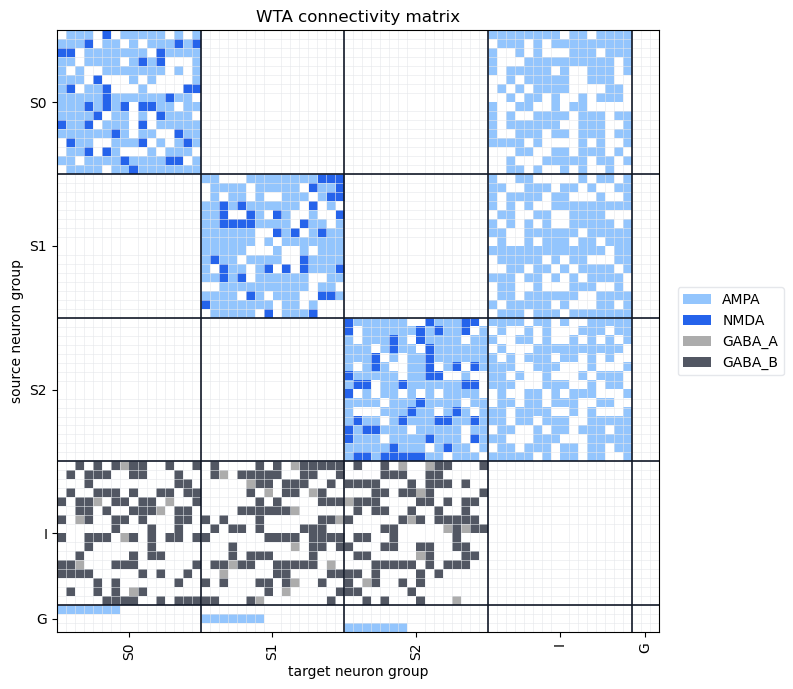

In [23]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


plt.clf()
plt.close("all")

fig, ax = plt.subplots(figsize=(8, 8))


# ------------------------------------------------------------
# DISCRETE SYNAPSE COLORS
# ------------------------------------------------------------
syn_colors = {
    "GABA_B": "#525763",
    "GABA_A": "#acacac",
    "none":   "#ffffff",
    "AMPA":   "#93c5fd",
    "NMDA":   "#2563eb",
}

colors = [
    syn_colors["GABA_B"],
    syn_colors["GABA_A"],
    syn_colors["none"],
    syn_colors["AMPA"],
    syn_colors["NMDA"],
]

cmap = ListedColormap(colors)

bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm   = BoundaryNorm(bounds, cmap.N)


# ------------------------------------------------------------
# CONNECTIVITY MATRIX
# ------------------------------------------------------------
im = ax.imshow(
    C,
    cmap          = cmap,
    norm          = norm,
    interpolation = "none",
    aspect        = "equal"
)


# ------------------------------------------------------------
# GROUP DEFINITIONS
# Matrix ordering assumed:
# S0, S1, ..., S_NS-1, G, I
# ------------------------------------------------------------
NG = NS          # one input generator per state population

group_specs = []

for s in range(NS):
    group_specs.append((f"S{s}", NE))

group_specs.append(("I", NI))
group_specs.append(("G", NG))

group_sizes  = [size for _, size in group_specs]
group_labels = [name for name, _ in group_specs]

N_plot = sum(group_sizes)

if C.shape != (N_plot, N_plot):
    raise ValueError(
        f"C has shape {C.shape}, but group sizes imply "
        f"({N_plot}, {N_plot}). Check group ordering or sizes."
    )


# ------------------------------------------------------------
# CELL GRID
# ------------------------------------------------------------
ax.set_xticks(np.arange(N_plot + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(N_plot + 1) - 0.5, minor=True)

ax.grid(
    which     = "minor",
    color     = "#e5e7eb",
    linestyle = "-",
    linewidth = 0.4
)

ax.tick_params(which="minor", bottom=False, left=False)


# ------------------------------------------------------------
# GROUP BOUNDARIES
# ------------------------------------------------------------
boundaries = np.cumsum(group_sizes)

boundary_color = "#111827"

for b in boundaries[:-1]:
    ax.axhline(b - 0.5, color=boundary_color, linewidth=1.2)
    ax.axvline(b - 0.5, color=boundary_color, linewidth=1.2)


# ------------------------------------------------------------
# GROUP LABELS
# ------------------------------------------------------------
centers = boundaries - np.array(group_sizes) / 2 - 0.5

ax.set_xticks(centers)
ax.set_yticks(centers)

ax.set_xticklabels(group_labels, rotation=90)
ax.set_yticklabels(group_labels)

ax.set_xlabel("target neuron group")
ax.set_ylabel("source neuron group")
ax.set_title("WTA connectivity matrix")


# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
legend_elements = [
    Patch(facecolor=syn_colors["AMPA"],   edgecolor="none", label="AMPA"),
    Patch(facecolor=syn_colors["NMDA"],   edgecolor="none", label="NMDA"),
    Patch(facecolor=syn_colors["GABA_A"], edgecolor="none", label="GABA_A"),
    Patch(facecolor=syn_colors["GABA_B"], edgecolor="none", label="GABA_B"),
]

ax.legend(
    handles    = legend_elements,
    loc        = "center left",
    bbox_to_anchor = (1.02, 0.5),
    frameon    = True,
    framealpha = 1.0,
    edgecolor  = "#e5e7eb"
)

plt.tight_layout()
plt.show()

In [14]:
# ------------------------------------------------------------
# APPLY CONFIGURATION
# ------------------------------------------------------------
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

set_params(model, param_group=param_group)

# ------------------------------------------------------------
# PREPARE POISSON INPUT
# ------------------------------------------------------------
global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
poisson_gen            = model.get_poisson_gen()
poisson_gen.set_chip_id(0)

# set initial rates to zero
for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

# ------------------------------------------------------------
# MONITOR NEURONS
# ------------------------------------------------------------
monitored_neurons = E_ids + I_ids
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()
# filter_node.set_neurons(monitored_neurons)

# clear buffer
sink_node.get_events()
api.reset_timestamp()

### **Create Input Spike-Train**

In [15]:
# ------------------------------------------------------------
# CREATE POISSON SPIKE TIMES
# ------------------------------------------------------------
spike_times  = []
indices      = []
target_chips = []

t0 = 0.0

for i, duration in enumerate(t_steps_stim):

    for gen_id, rate in zip(global_poisson_gen_ids, stim_rates_hz[i]):

        n_spikes = np.random.poisson(rate * duration)
        
        times = t0 + np.sort(np.random.rand(n_spikes) * duration)
        
        spike_times.extend(times)
        indices.extend([gen_id] * n_spikes)
        target_chips.extend([0] * n_spikes)

    t0 += duration


# Then sort all spikes globally in time:
spike_times  = np.array(spike_times)
indices      = np.array(indices)
target_chips = np.array(target_chips)

sort_idx = np.argsort(spike_times)

spike_times  = spike_times[sort_idx]
indices      = indices[sort_idx]
target_chips = target_chips[sort_idx]


# Then load the stimulus:
fpga_spike_gen = model.get_fpga_spike_gen()

ut.set_fpga_spike_gen(
    fpga_spike_gen = fpga_spike_gen,
    spike_times    = spike_times,
    indices        = indices,
    target_chips   = target_chips,
    isi_base       = 900,
    repeat_mode    = False
)

RepeatMode already 0


In [16]:
from tools.spikegen_tools import get_instantaneous_activity

# ------------------------------------------------------------
# INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
activity_dt_s = 0.2
exp_tc_s      = 0.02


def population_activity(t_spikes, n_neurons):
    t_spikes = np.asarray(t_spikes, dtype=float)
    t_spikes = np.sort(t_spikes[(t_spikes >= 0) & (t_spikes < t_tot)])

    if len(t_spikes) == 0:
        activity_x    = np.arange(0, t_tot, activity_dt_s)
        activity_rate = np.zeros_like(activity_x)
        return activity_rate, activity_x

    activity_hz, activity_x = get_instantaneous_activity(
        t_spikes,
        activity_dt_s,
        exp_tc_s
    )

    activity_hz = np.asarray(activity_hz, dtype=float)
    activity_x  = np.asarray(activity_x, dtype=float)

    mask = activity_x < t_tot

    activity_rate = activity_hz[mask] / n_neurons
    activity_x    = activity_x[mask]

    return activity_rate, activity_x


### **Plot Stimulation Rates**

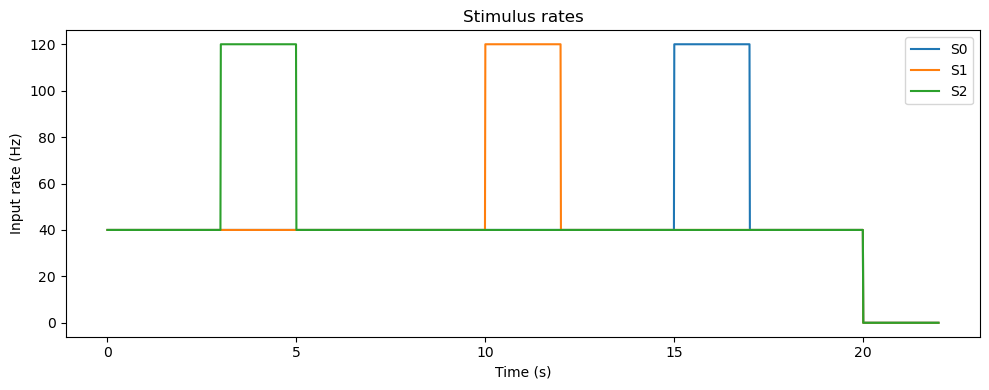

In [17]:

fs = 100

stim_rates_hz = np.array(stim_rates_hz)
t             = np.arange(0, t_tot, 1/fs)

# allocate rate matrix
rates = np.zeros((NS, len(t)))

# fill piecewise constant segments
t_cursor = 0
for i, dt in enumerate(t_steps_stim):
    idx_start = int(t_cursor * fs)
    idx_end   = int((t_cursor + dt) * fs)

    for s in range(NS):
        rates[s, idx_start:idx_end] = stim_rates_hz[i, s]

    t_cursor += dt

plt.figure(figsize=(10,4))

for s in range(NS):
    plt.plot(t, rates[s], label=f"S{s}")

plt.xlabel("Time (s)")
plt.ylabel("Input rate (Hz)")
plt.title("Stimulus rates")
plt.legend()
plt.tight_layout()
plt.show()


### **Run Simulation**

In [18]:
# Run Simulation
fpga_spike_gen.start()
time.sleep(t0)
fpga_spike_gen.stop()

# turn off stimulus

for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

poisson_gen.stop()
time.sleep(t_tot)

graph.stop()
events = sink_node.get_events()

print(f"{len(events)} events recorded.")

PoissonGen already off!
6227 events recorded.


### **Post Simulation Processing**

In [19]:
# ------------------------------------------------------------
# EXTRACT EVENTS
# ------------------------------------------------------------
spike_id = []
spike_t  = []

for evt in events:
    spike_id.append(evt.neuron_id)
    spike_t.append(evt.timestamp * 1e-6)

spike_id = np.array(spike_id)
spike_t  = np.array(spike_t)


# ------------------------------------------------------------
# FILTER SPIKES BY POPULATION
# ------------------------------------------------------------
S_spike_t  = []
S_spike_id = []

for s in range(int(NS)):
    lower = s * NE
    upper = (s + 1) * NE

    mask = (spike_id > lower) & (spike_id <= upper)

    S_spike_t.append(spike_t[mask])
    S_spike_id.append(spike_id[mask])

mask_I = spike_id > NS * NE

I_spike_t  = spike_t[mask_I]
I_spike_id = spike_id[mask_I]


# ------------------------------------------------------------
# BIN FILTERED SPIKES
# ------------------------------------------------------------
fs     = 1.2
n_bins = int(t_tot * fs)

binPOP = np.zeros((NS + 1, n_bins))

for s in range(int(NS + 1)):

    if s < NS:
        t_spikes = S_spike_t[s]
    else:
        t_spikes = I_spike_t   # last row = inhibitory population

    t_spikes = t_spikes[t_spikes < t_tot]

    counts, _ = np.histogram(
        t_spikes,
        bins=n_bins,
        range=(0, t_tot)
    )

    binPOP[s, :] = counts

# total excitatory activity (all S populations pooled)
binPOP_E = np.sum(binPOP[:NS, :], axis=0)

# Mean excitatory activity (all S populations pooled)
binPOP_tot_mean = np.sum(binPOP) / (NS * NE)


# ------------------------------------------------------------
# POPULATION FIRING ACTIVITY
# ------------------------------------------------------------
idx_end = int(t_tot * fs)
t_axis  = np.arange(idx_end) / fs

binPOP_rate = binPOP[:, :idx_end] * fs / NE

# ---------------------------------------------------------
# FIRING ACTIVITY PER STIMULUS WINDOW
# ------------------------------------------------------------

#TODO Make independent of binPOP

stim_start = np.cumsum(np.r_[0, t_steps_stim[:-1]])
stim_end   = stim_start + t_steps_stim

out_rates = np.zeros((NS, len(stim_rates)))

for s in range(int(NS)):
    for i, (t0, t1) in enumerate(zip(stim_start, stim_end)):
        b0 = int(t0 * fs)
        b1 = int(t1 * fs)

        n_spikes = np.sum(binPOP[s, b0:b1])

        out_rates[s, i] = n_spikes / (t1 - t0)




In [20]:
S_activity_rate = []
S_activity_x    = []

for s in range(int(NS)):
    rate, x = population_activity(S_spike_t[s], NE)

    S_activity_rate.append(rate)
    S_activity_x.append(x)


I_activity_rate, I_activity_x = population_activity(I_spike_t, NI)


# total excitatory activity, all S populations pooled
E_spike_t = np.concatenate(S_spike_t)

E_activity_rate, E_activity_x = population_activity(
    E_spike_t,
    int(NS) * NE
)

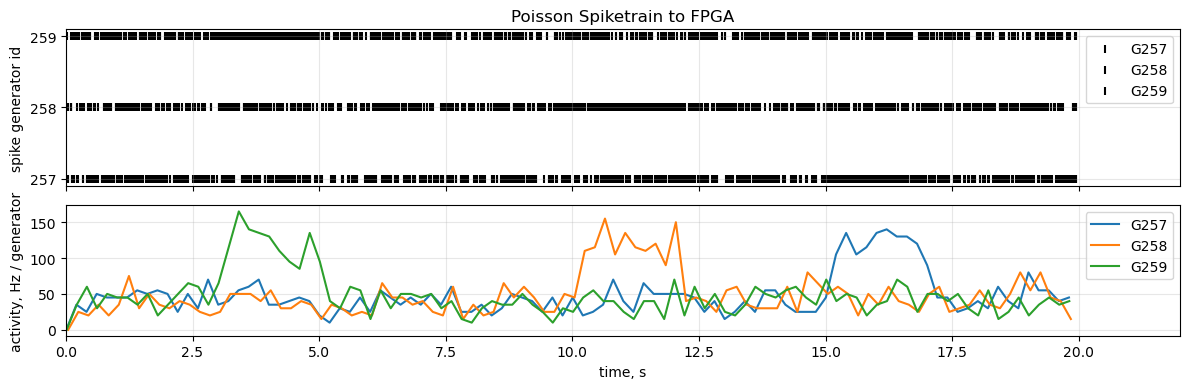

In [21]:
input_spike_t  = np.asarray(spike_times)
input_spike_id = np.asarray(indices)

color_in = 'black'

# ------------------------------------------------------------
# COMPUTE INPUT GENERATOR ACTIVITY
# ------------------------------------------------------------
G_activity_rate = []
G_activity_x    = []
G_ids           = np.unique(input_spike_id)

for gid in G_ids:
    mask = input_spike_id == gid
    rate, x = population_activity(input_spike_t[mask], n_neurons=10)

    G_activity_rate.append(rate)
    G_activity_x.append(x)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1]}
)

# ------------------------------------------------------------
# RASTER
# ------------------------------------------------------------
for gid in G_ids:
    mask = input_spike_id == gid

    ax1.scatter(
        input_spike_t[mask],
        input_spike_id[mask],
        marker='|',
        s=30,
        color=color_in,
        label=f'G{gid}'
    )

ax1.set_ylabel('spike generator id')
ax1.set_title('Poisson Spiketrain to FPGA')

ax1.set_yticks(G_ids)
ax1.set_yticklabels([str(int(gid)) for gid in G_ids])

ax1.grid(True, alpha=0.3)
ax1.legend()

# ------------------------------------------------------------
# INSTANTANEOUS ACTIVITY
# ------------------------------------------------------------
for k, gid in enumerate(G_ids):
    ax2.plot(
        G_activity_x[k],
        G_activity_rate[k],
        linestyle='-',
        label=f'G{gid}'
    )

ax2.set_xlabel('time, s')
ax2.set_ylabel('activity, Hz / generator')
ax2.set_xlim(0, t_tot)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

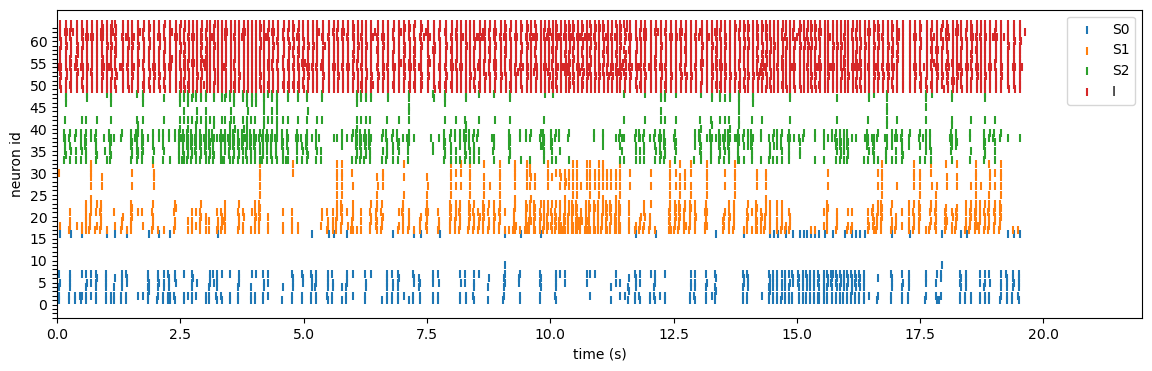

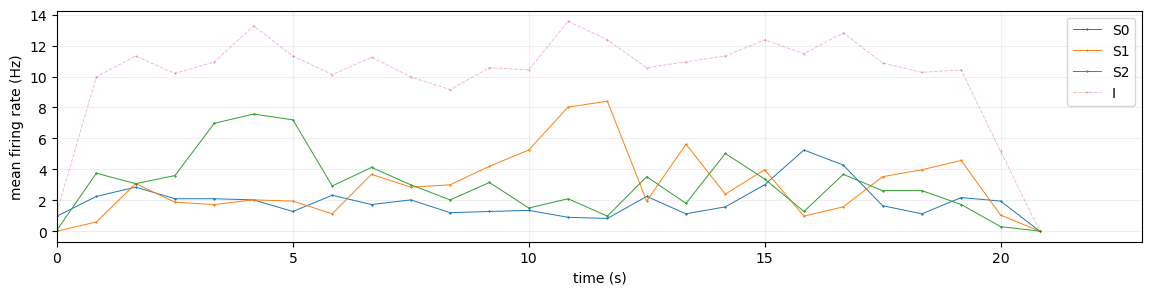

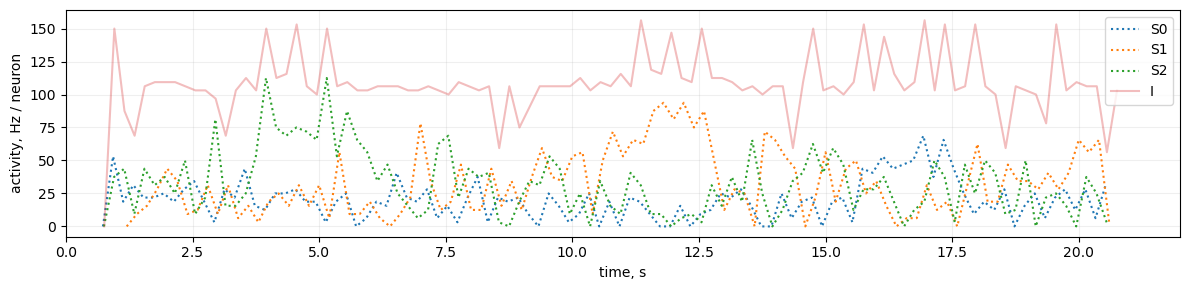

In [22]:
color_I  = 'tab:red'
color_S  = ['tab:blue', 'tab:orange', 'tab:green', color_I]  # one per S population

# ------------------------------------------------------------
# TIME SHIFT
# ------------------------------------------------------------
t_0 = 1.2   # seconds, set this to the time you want to subtract


# ------------------------------------------------------------
# PLOT SPIKE RASTER
# ------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(14, 4))

for s in range(int(NS)):
    ax1.scatter(
        S_spike_t[s] - t_0,
        S_spike_id[s],
        marker='|',
        color=color_S[s],
        label=f'S{s}'
    )

if I_spike_t.size > 0:
    ax1.scatter(
        I_spike_t - t_0,
        I_spike_id,
        marker='|',
        color=color_I,
        label='I'
    )

"""
ax1.scatter(
    input_spike_t - t_0,
    -1 * np.ones_like(input_spike_t),
    marker='|',
    color=color_in,
    label='Input'
)
"""

ticks = np.arange(-NG, NS*NE + NI, 1)
ax1.set_yticks(ticks)

# show labels only every k neurons
k = 5
labels = [str(t) if t % k == 0 else '' for t in ticks]
ax1.set_yticklabels(labels)

ax1.set_xlabel('time (s)')
ax1.set_ylabel('neuron id')

ax1.set_xlim(0, t_tot)

ax1.legend()
# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST TIME
# ------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(14, 3))

for s in range(int(NS)):
    ax2.plot(
        t_axis,
        binPOP_rate[s],
        marker      = '*',
        linestyle   = '-',
        linewidth = 0.7,
        color       = color_S[s],
        markersize  = 1,
        label       = f'S{s}'
    )

if I_spike_t.size > 0:
     ax2.plot(
            t_axis,
            binPOP_rate[NS],
            marker     = '*',
            linestyle  = '--',
            color      = color_I,
            markersize = 1,
            alpha = 0.3,
            linewidth = 0.7,
            label      = f'I'
        )

ax2.set_xlabel('time (s)')
ax2.set_ylabel('mean firing rate (Hz)')
ax2.grid(True, alpha=0.2)
ax2.set_xlim(0, t_tot+1)
ax2.legend()

# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST INPUT STIMULUS
# ------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(12, 3))

for s in range(int(NS)):
    ax3.plot(
        S_activity_x[s],
        S_activity_rate[s],
        linestyle  = ':',
        alpha = 1,
        color       = color_S[s],
        label=f"S{s}"
    )

if I_spike_t.size > 0:
    ax3.plot(
        I_activity_x,
        I_activity_rate,
        linestyle  = '-',
        alpha = 0.3,
        color = color_I,
        label="I"
    )

ax3.set_xlabel("time, s")
ax3.set_ylabel("activity, Hz / neuron")
ax3.set_xlim(0, t_tot)
ax3.legend()
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

